Nuscenes: https://colab.research.google.com/github/nutonomy/nuscenes-devkit/blob/master/python-sdk/tutorials/nuscenes_tutorial.ipynb#scrollTo=Q0WfcmMM2TMa

Open3d: https://colab.research.google.com/drive/1lwLt3j5vEilNKPSqPir0nH7aT8MwGIgZ?usp=sharing#scrollTo=w2Zgsfonla65

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from tqdm.notebook import tqdm
from PIL import Image

import tensorflow as tf

import os

from google.colab import drive
drive.mount("/content/drive")

TORCH_version = torch.__version__.split('+')[0]
CUDA_version = torch.version.cuda.replace('.', '')

!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-{TORCH_version}+cu{CUDA_version}.html

!pip install torch_geometric

import torch_geometric as pyg

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MLP, global_add_pool
from torch_geometric.nn.conv import HANConv

from torch_geometric.transforms import NormalizeFeatures

!pip install open3d plotly

import open3d as o3d
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html


In [2]:
!mkdir -p /data/sets/nuscenes  # Make the directory to store the nuScenes dataset in.

#!cp "/content/drive/MyDrive/LiDARFusion/v1.0-mini.tgz" "/data/sets/nuscenes"

!tar -xf "/content/drive/MyDrive/LiDARFusion/v1.0-mini.tgz" -C /data/sets/nuscenes  # Uncompress the nuScenes mini split.

!pip install nuscenes-devkit &> /dev/null  # Install nuScenes.

In [3]:
import sys

sys.path.insert(0, '/content/drive/MyDrive/LiDARFusion')

from voxel_pointnet2 import PointNetSetAbstraction

#each voxel is encoded as [B,N,C]. B=batch dimension, N = max num per voxel, C is either features, or 3 if coordinates
#a [B,N] mask controls which points in a batch are considered padding, and which are considered actual points for processing
#raw coordinates and raw features are often stored in separate variables, coordinates -> xyz, features -> points
#npoint is how many centroids to select, nsample is how many points exist in each centroid neighborhood

In [4]:
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
nusc_root = "/data/sets/nuscenes"

nusc = NuScenes(version='v1.0-mini', dataroot=nusc_root, verbose=True)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.906 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


nusc.get("sample_data", id for sensor), id is through sample["data"]["Sensor name"]

nusc.render_sample_data(data["token"])

In [8]:
my_scene = nusc.scene[0] #0-9
first_sample_token = my_scene['first_sample_token']
my_sample = nusc.get('sample', first_sample_token)
lidar_data = nusc.get('sample_data', my_sample['data']["LIDAR_TOP"])
#nusc.render_sample_data(cam_front_data['token'])
lidar_data_path = os.path.join(nusc_root, lidar_data["filename"])
pc = LidarPointCloud.from_file(lidar_data_path)

In [13]:
pc_xyz = pc.points[:3, :].T
#o_xyz = o3d.utility.Vector3dVector(pc_xyz)

pcd_xyz = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(pc_xyz))

o3d.visualization.draw_plotly([pcd_xyz])

When changing to storing on drive, only need to change the nusc_root data path

In [32]:
def extract_clouds(scene, data_root):

  scene_tokens = []
  token_0 = scene["first_sample_token"]

  while token_0 != "":
    scene_tokens.append(token_0)

    token_sample = nusc.get("sample", token_0)
    token_0 = token_sample["next"]

  scene_clouds = []

  for i in range(len(scene_tokens)):
    cloud_sample = nusc.get("sample", scene_tokens[i])
    cloud_data = nusc.get("sample_data", cloud_sample["data"]["LIDAR_TOP"])

    cloud_root = os.path.join(data_root, cloud_data["filename"])

    cloud = LidarPointCloud.from_file(cloud_root)

    cloud_xyz = cloud.points[:3, :].T

    lidar_cloud = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(cloud_xyz))

    scene_clouds.append(lidar_cloud)

  return scene_clouds


In [49]:
def get_voxels(cloud, voxel_size = 0.1):

  voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(cloud, voxel_size=voxel_size)

  min_bound = voxel_grid.get_min_bound()
  max_bound = voxel_grid.get_max_bound()

  voxel_shape = np.ceil((max_bound - min_bound) / voxel_size).astype(int)
  voxels_tensor = np.zeros(grid_shape, dtype=np.float32)

  for voxel in voxel_grid.get_voxels():
    grid_index = voxel.grid_index
    voxels_tensor[grid_index[0], grid_index[1], grid_index[2]] = 1.0

  return voxels_tensor



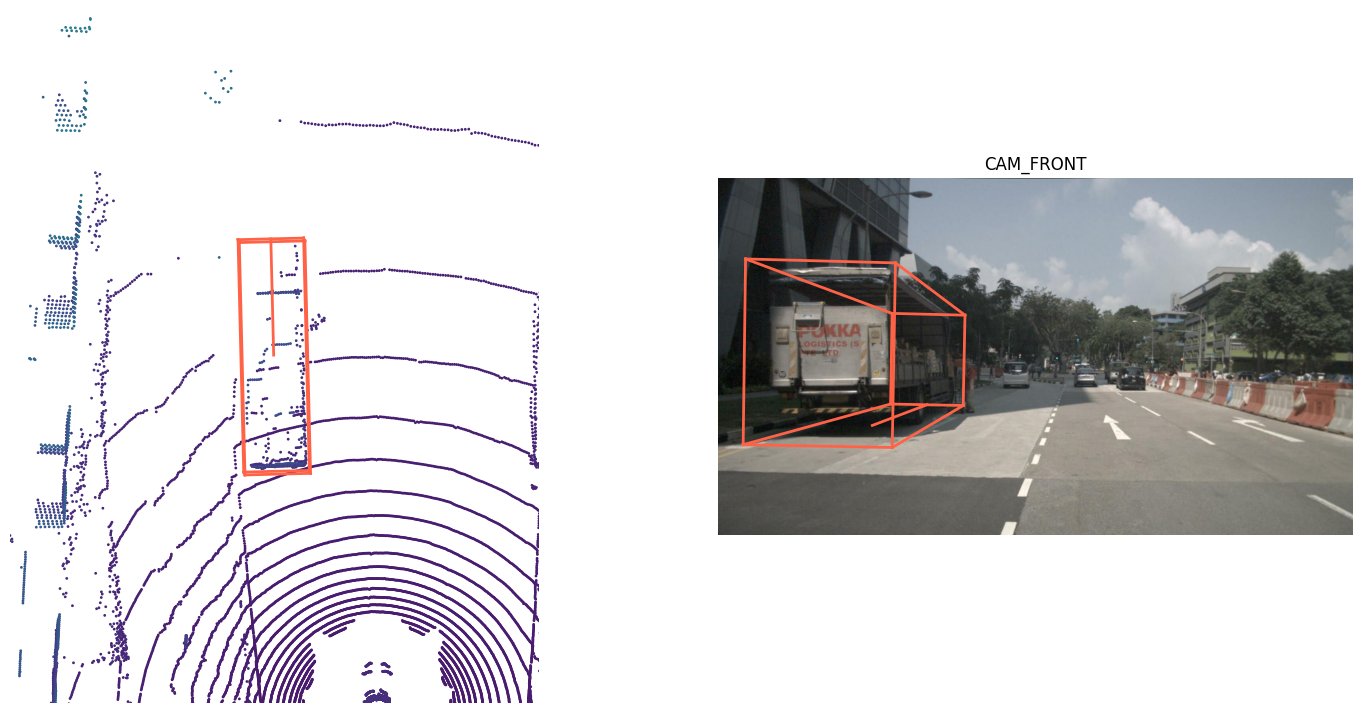

In [29]:
annotation_token = my_sample["anns"][18]
annotation_metadata =  nusc.get('sample_annotation', annotation_token)
nusc.render_annotation(annotation_token)